In [2]:
import os
import json
import matplotlib.pyplot as plt
import tiktoken

import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

from PIL import Image

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using Device : {device}\nDevice Name  : {torch.cuda.get_device_name(0)}")


Using Device : cuda
Device Name  : NVIDIA GeForce GTX 1650


In [3]:
class CocoDataset(Dataset):
    def __init__(self, image_dir, annotation_file, transform=None, tokenizer=None):
        self.image_dir = image_dir
        self.transform = transform
        self.tokenizer = tokenizer

        with open(annotation_file, 'r') as f:
            data = json.load(f)

        # build (image, caption) pairs
        self.samples = []
        self.max_len = 30 # found by data/coco2017/annotations/data_analysis.ipynb
        for file_name, captions in data.items():
            for caption in captions:
                caption = self.tokenizer.encode(caption)
                if len(caption)>self.max_len-2:
                    caption = caption[:self.max_len-2]
                caption = [50257] + caption + [50258] # <Start> caption <END>
                if len(caption)<self.max_len:
                    total_pads_to_add = self.max_len - (len(caption) + 2)
                    caption = caption + [50259] * total_pads_to_add
                self.samples.append((file_name, caption))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        file_name, caption = self.samples[idx]

        img_path = os.path.join(self.image_dir, file_name)
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, caption


In [4]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [5]:
tokenizer = tiktoken.get_encoding("gpt2")

special_tokens = {
    "<START>": 50257,
    "<END>": 50258,
    "<PAD>": 50259,
}

tokenizer = tiktoken.Encoding(
    name="gpt2_extended",
    pat_str=tokenizer._pat_str,
    mergeable_ranks=tokenizer._mergeable_ranks,
    special_tokens=special_tokens
)


In [6]:
train_dataset = CocoDataset(
    image_dir="data/coco2017/train2017",
    annotation_file="data/coco2017/annotations/train_captions_custom.json",
    transform=train_transform,
    tokenizer=tokenizer
)

val_dataset = CocoDataset(
    image_dir="data/coco2017/val2017",
    annotation_file="data/coco2017/annotations/val_captions_custom.json",
    transform=val_transform,
    tokenizer=tokenizer
)

train_dataloader = DataLoader(train_dataset, batch_size=1, shuffle=True)
test_dataloader = DataLoader(val_dataset, batch_size=1, shuffle=False)


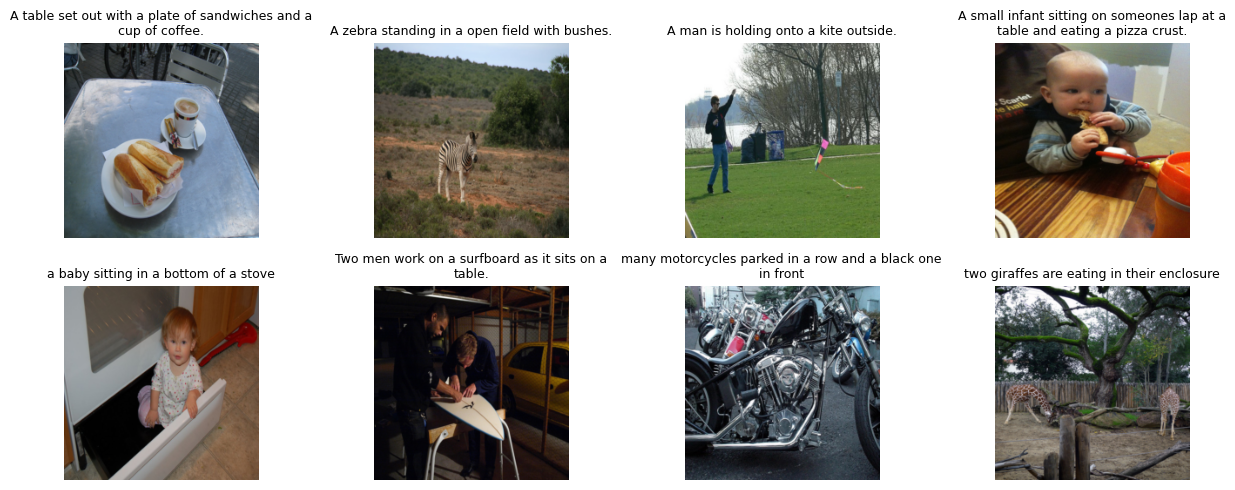

In [11]:
import random
import textwrap

# Random sample visualization (raw captions from dataset; tensor view matches val preprocessing)
indices = random.sample(range(len(train_dataset)), k=min(8, len(train_dataset)))
fig, axes = plt.subplots(2, 4, figsize=(13, 5))
axes = axes.flatten()
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
for ax, idx in zip(axes, indices):
    file_name, caption = train_dataset.samples[idx]
    img_path = os.path.join(train_dataset.image_dir, file_name)
    pil_img = Image.open(img_path).convert("RGB")
    tensor = val_transform(pil_img)
    vis = (tensor * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    ax.imshow(vis)
    ax.set_title(textwrap.fill(tokenizer.decode(caption[1:caption.index(50258)]), width=48), fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()


In [8]:
class Encoder(nn.Module):
    """takes (batch, 3_channels, 244, 244) image as input after transformation"""
    def __init__(self) -> None:
        super().__init__()
        resnet_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        modules = list(resnet_model.children())[:-2] # removing ff layer and average pool to conserve features
        self.encoder = nn.Sequential(*modules) # creating a forward model with frozen parameters
            
        for param in self.encoder.parameters():
            param.requires_grad = False
    
    def forward(self, x):
        return self.encoder(x)

In [ ]:
class RNN_Caption(nn.Module):
    def __init__(self, config, tokenizer_vocab_size):
        super().__init__()
        self.config = config

        self.wte = nn.Embedding(tokenizer_vocab_size ,config.d_model)
        self.encoder_transform = nn.Linear(2048, config.d_model)
        self.decoder = nn.RNN(input_size=config.d_model, hidden_size=config.d_model*49, num_layers=2, batch_first=True)
        self.fc = nn.Linear(config.d_model, vocab_size)

        self.drop = nn.Dropout(config.droupout)
        self.encoder = Encoder()
        
        self.teacher_forcing_ratio = 0.9
    def forward(self, images):
        B = images.size(0)

        x = self.encoder(images)
        x = x.flatten(2)          # (B, 2048, 49)
        x = x.permute(0, 2, 1)   # (B, 49, 2048)
        x = self.encoder_transform(x) # (B, 49, d_model)
        h0 = x.view(B, 49*self.config.d_model)

        input_token = torch.full((B, 1), 50257, device=images.device)
        input_emb = self.wte(input_token)
        max_length = 30
        outputs = []
        
        for t in range(max_length):
            out, h0 = self.decoder(input_emb, h0)

            logits = self.wtue(out)  # (B, 1, vocab_size)
            outputs.append(logits)

            # teacher forcing
            if captions is not None and torch.rand(1).item() < self.teacher_forcing_ratio:
                next_token = captions[:, t].unsqueeze(1)
            else:
                next_token = logits.argmax(-1)

            input_emb = self.wte(next_token)

        outputs = torch.cat(outputs, dim=1)
        return outputs
        

        

In [ ]:
class Config:
    d_model = 512
    context_length = 30


In [ ]:
proj = nn.Linear(2048, 512)
features = proj(features)


In [ ]:
sorted(train_dataset.samples, key=lambda x: len(x[1]))
